In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
annual_data = pd.read_csv("../data/cleaned/BunkerByCategoryLong.csv")
annual_data = annual_data.set_index("year")
annual_data

,index,fuel_category,bunker_sales
year,,,
1995,0,Alternative,0.00
1995,1,LNG,0.00
1995,2,LSFO,0.00
1995,3,LSMGO,0.00
1995,4,MDO,700.10
...,...,...,...
2025,243,LSMGO,4251.65
2025,244,MDO,0.00
2025,245,MFO,22085.55


In [31]:
yearly = annual_data.groupby("year")["bunker_sales"].sum().reset_index()
yearly

,year,bunker_sales
0,1995,17489.20
1,1996,16938.48
2,1997,16940.75
3,1998,18063.82
4,1999,18891.20
5,2000,18650.79
6,2001,20351.67
7,2002,20096.38
8,2003,20808.97
9,2004,23566.87


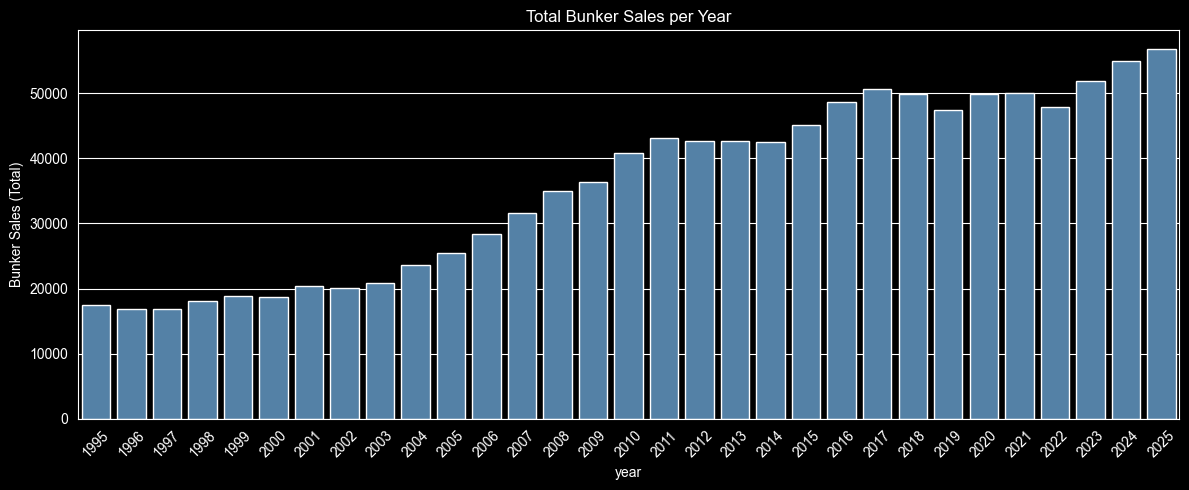

In [37]:
plt.figure(figsize=(12, 5))
sns.barplot(data=yearly, x="year", y="bunker_sales", color="steelblue")
plt.ylabel("Bunker Sales (Total)")
plt.title("Total Bunker Sales per Year")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [39]:
yearly["yoy_growth"] = yearly["bunker_sales"].pct_change() * 100

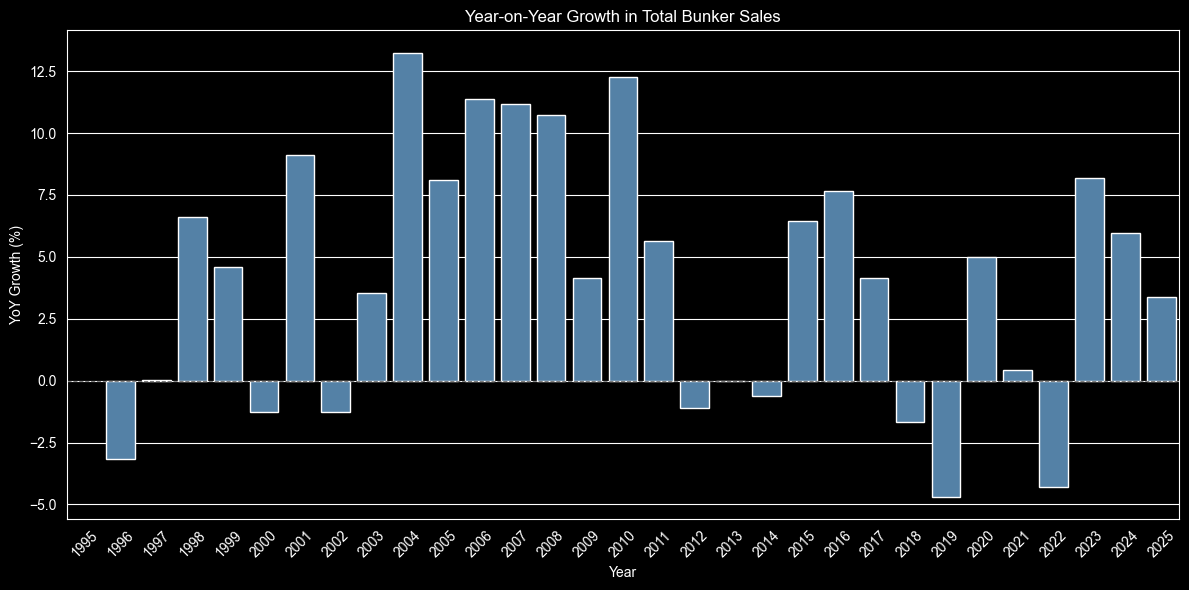

In [40]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=yearly, x="year", y="yoy_growth", ax=ax, color="steelblue")
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_xlabel("Year")
ax.set_ylabel("YoY Growth (%)")
ax.set_title("Year-on-Year Growth in Total Bunker Sales")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

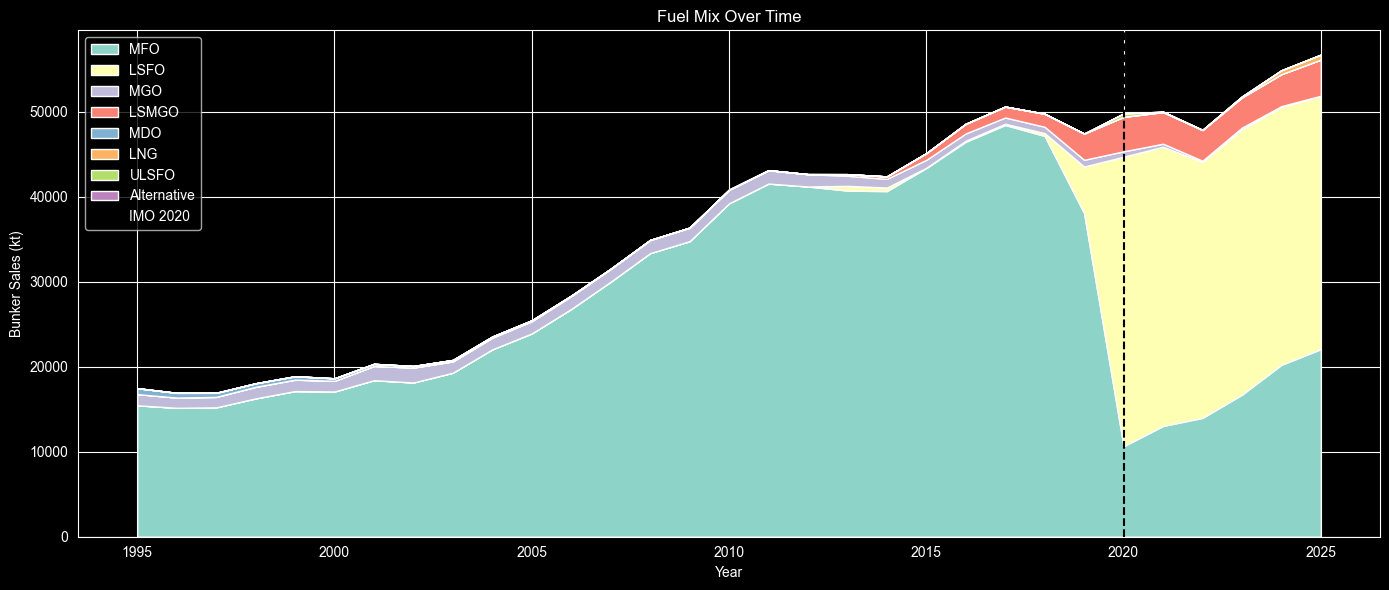

In [44]:
annual_wide = pd.read_csv("../data/cleaned/BunkerByCategoryWide.csv")
annual_wide = annual_wide.set_index("year")
order = annual_wide.sum().sort_values(ascending=False).index.tolist()
fig, ax = plt.subplots(figsize=(14, 6))
ax.stackplot(annual_wide.index, [annual_wide[c] for c in order], labels=order)
ax.axvline(2020, color='black', linestyle='--', linewidth=1.5, label='IMO 2020')
ax.set_xlabel('Year')
ax.set_ylabel('Bunker Sales (kt)')
ax.set_title('Fuel Mix Over Time')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()


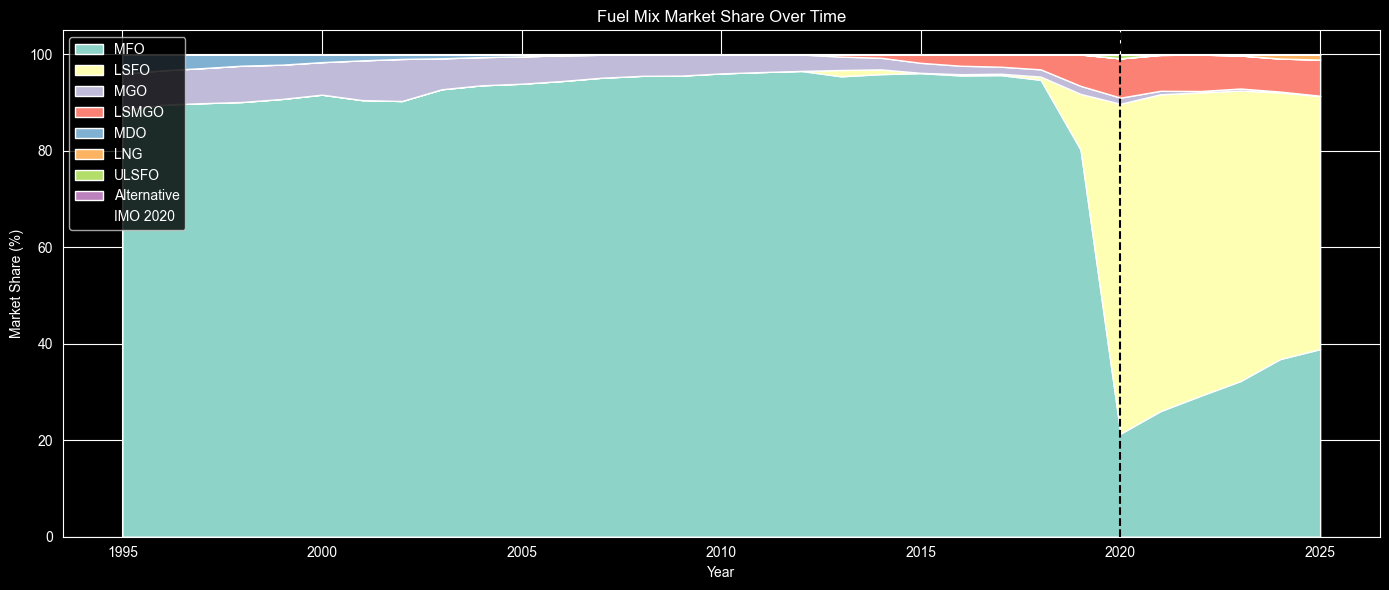

In [51]:
pct = annual_wide.div(annual_wide.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 6))
ax.stackplot(pct.index, [pct[c] for c in order], labels=order)
ax.axvline(2020, color='black', linestyle='--', linewidth=1.5, label='IMO 2020')
ax.set_xlabel('Year')
ax.set_ylabel('Market Share (%)')
ax.set_title('Fuel Mix Market Share Over Time')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()



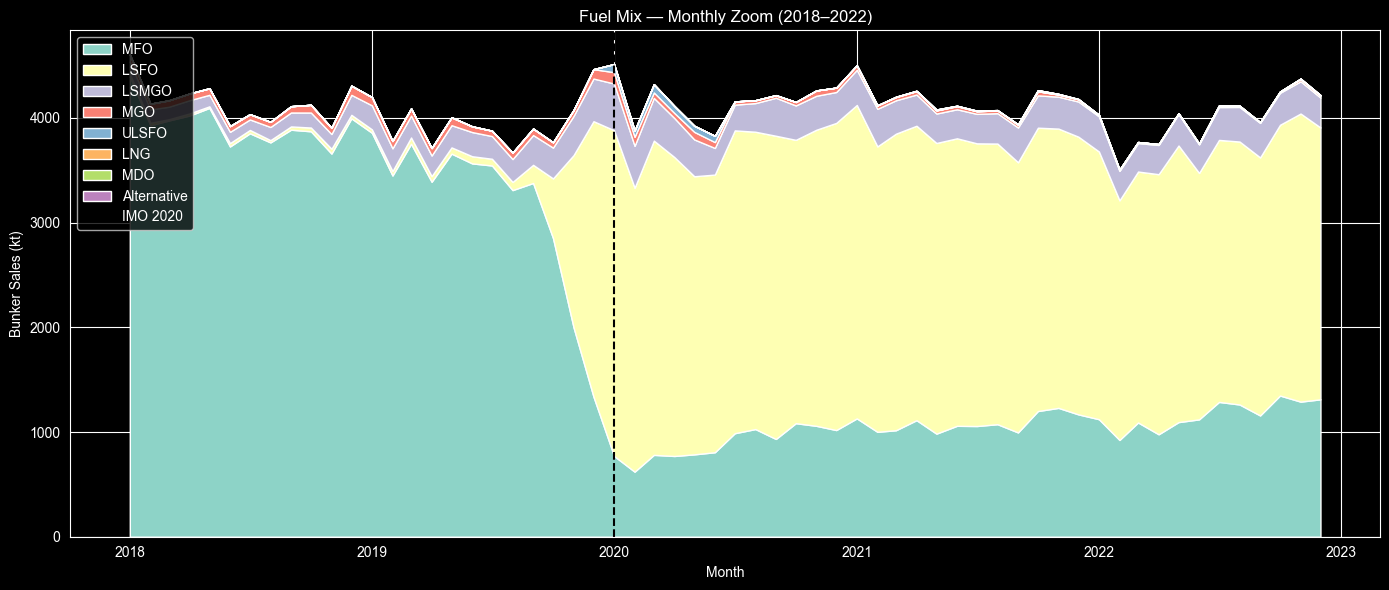

In [48]:
monthly_clean = pd.read_csv("../data/cleaned/BunkerByCategoryMonthly.csv", parse_dates=['month'])
monthly = monthly_clean.groupby(['month', 'fuel_category'])['bunker_sales'].sum().reset_index()
monthly_pivot = monthly.pivot_table(index='month', columns='fuel_category', values='bunker_sales', fill_value=0).sort_index()

zoom = monthly_pivot.loc['2018':'2022']
zoom_order = zoom.sum().sort_values(ascending=False).index.tolist()

fig, ax = plt.subplots(figsize=(14, 6))
ax.stackplot(zoom.index, [zoom[c] for c in zoom_order], labels=zoom_order)
ax.axvline(pd.Timestamp('2020-01-01'), color='black', linestyle='--', linewidth=1.5, label='IMO 2020')
ax.set_xlabel('Month')
ax.set_ylabel('Bunker Sales (kt)')
ax.set_title('Fuel Mix — Monthly Zoom (2018–2022)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()
